# PLANET: Predictive Learning Approach for Non-Solar Environment Tracking
## Phase 1: Machine Learning Backend
This notebook fetches real data from the NASA Exoplanet Archive to train an XGBoost model to predict exoplanet habitability.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import ipywidgets as widgets
from IPython.display import display, clear_output
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

# 1. Data Acquisition (Real Data from NASA Exoplanet Archive)
print("Fetching data from NASA Exoplanet Archive...")
nasa_data = NasaExoplanetArchive.query_criteria(
    table="ps",
    select="hostname,pl_name,pl_rade,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass",
    where="pl_rade IS NOT NULL AND pl_orbsmax IS NOT NULL AND pl_eqt IS NOT NULL AND st_teff IS NOT NULL AND st_rad IS NOT NULL AND st_mass IS NOT NULL"
)
df = nasa_data.to_pandas()
df = df.drop_duplicates(subset=['pl_name'])
print(f"Fetched {len(df)} unique exoplanets with complete feature data.")

# 2. Target Variable: is_habitable
# 1 if Planet Temp is 200K-320K AND radius < 2.5 Earth radii, else 0
df['is_habitable'] = ((df['pl_eqt'] >= 200) & (df['pl_eqt'] <= 320) & (df['pl_rade'] < 2.5)).astype(int)

print(f"Total Habitable Planets in Dataset: {df['is_habitable'].sum()}")
df.head()

Fetching data from NASA Exoplanet Archive...
Fetched 4130 unique exoplanets with complete feature data.
Total Habitable Planets in Dataset: 68


,hostname,pl_name,pl_rade,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,is_habitable
0,TOI-4010,TOI-4010 b,3.020000,0.02290,1441.0,4960.0,0.8300,0.880,0
1,TOI-2384,TOI-2384 b,11.489205,0.02793,889.7,3943.0,0.6113,0.635,0
2,K2-321,K2-321 b,1.950000,0.04100,701.0,3855.0,0.5830,0.599,0
3,HAT-P-28,HAT-P-28 b,13.585000,0.04340,1384.0,5680.0,1.1030,1.025,0
4,HD 3167,HD 3167 c,2.860000,0.18410,531.0,5528.0,0.8700,0.940,0


Found 63 Target Pixel Files for Kepler-62.


Successfully processed 63 TPFs.


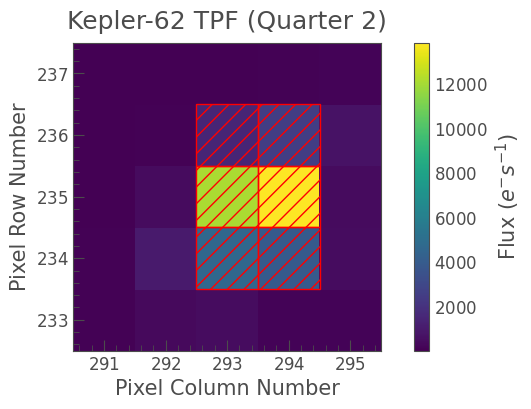

In [2]:
# 2a. Visual Data: Fetch Target Pixel File (TPF) using lightkurve
import lightkurve as lk
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings

# Suppress occasional lightkurve download warnings for a cleaner output
warnings.filterwarnings('ignore')

# Search for the Target Pixel File (TPF) for Kepler-62
search_result = lk.search_targetpixelfile("Kepler-62")
print(f"Found {len(search_result)} Target Pixel Files for Kepler-62.")

# Download files individually inside a tqdm loop to create a progress bar
tpf_list = []
for i in tqdm(range(len(search_result)), desc="Downloading & Analyzing TPFs", unit="file"):
    tpf = search_result[i].download()
    if tpf is not None:
        tpf_list.append(tpf)

# Convert the list back into a Lightkurve Collection
tpfs = lk.TargetPixelFileCollection(tpf_list)
print(f"Successfully processed {len(tpfs)} TPFs.")

# Plot the telescope's actual pixel view using its pipeline mask for the first TPF
if len(tpfs) > 0:
    tpf = tpfs[0]
    tpf.plot(aperture_mask=tpf.pipeline_mask, title=f"Kepler-62 TPF (Quarter {tpf.quarter})")
    plt.show()

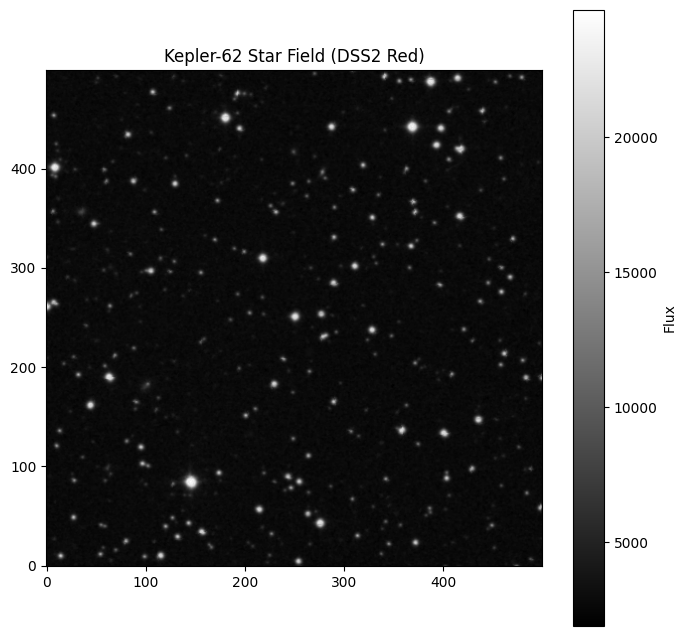

In [3]:
# 2b. Visual Data: Fetch Digitized Sky Survey (DSS) image using astroquery
from astroquery.skyview import SkyView
import matplotlib.pyplot as plt

# Query the Digitized Sky Survey (DSS) for a 500x500 pixel image of the Kepler-62 star field
# We use DSS2 Red as a standard optical survey
paths = SkyView.get_images(position='Kepler-62', survey=['DSS2 Red'], pixels=500)

# The result is a list of HDU objects. We take the first one.
hdu = paths[0][0]
image_data = hdu.data

# Plot the FITS image using matplotlib with a grayscale colormap
plt.figure(figsize=(8, 8))
plt.imshow(image_data, cmap='gray', origin='lower')
plt.title("Kepler-62 Star Field (DSS2 Red)")
plt.colorbar(label='Flux')
plt.show()

Fetching Lightcurve data for Kepler-62...


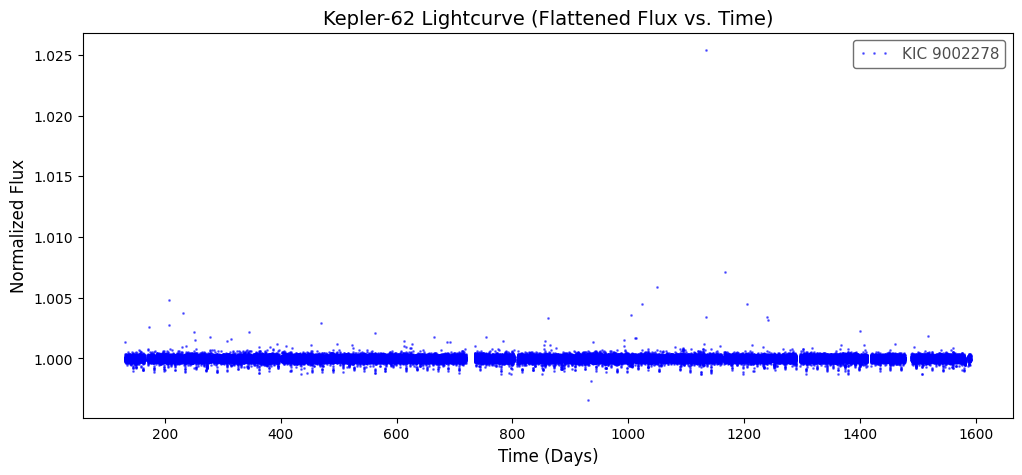

In [15]:
# 2c. Visual Data: Fetch and Render the Lightcurve Graph
import lightkurve as lk
import matplotlib.pyplot as plt

print("Fetching Lightcurve data for Kepler-62...")
# Search for the lightcurve data for a specific star (e.g., Kepler-62)
search_result_lc = lk.search_lightcurve("Kepler-62", author="Kepler", exptime=1800)

# Download all available quarters and stitch them together
lc_collection = search_result_lc.download_all()
lc = lc_collection.stitch().flatten()

# Plot the Lightcurve graph
fig, ax = plt.subplots(figsize=(12, 5))
lc.plot(ax=ax, linewidth=0, marker='.', markersize=2, color='blue', alpha=0.5)
ax.set_title("Kepler-62 Lightcurve (Flattened Flux vs. Time)", fontsize=14)
ax.set_ylabel("Normalized Flux", fontsize=12)
ax.set_xlabel("Time (Days)", fontsize=12)
plt.show()

In [16]:
# 3. ML Model: Train XGBoost Classifier & Algorithm Visualizations
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

X = df[['pl_rade', 'pl_orbsmax', 'pl_eqt', 'st_teff', 'st_rad', 'st_mass']]
y = df['is_habitable']

# Split into 80% training data and 20% testing data, stratifying by y to ensure balanced testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples.")
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# Generate standard predictions and probability predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Training on 3304 samples, testing on 826 samples.
Accuracy: 0.9987893462469734

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       812
           1       1.00      0.93      0.96        14

    accuracy                           1.00       826
   macro avg       1.00      0.96      0.98       826
weighted avg       1.00      1.00      1.00       826



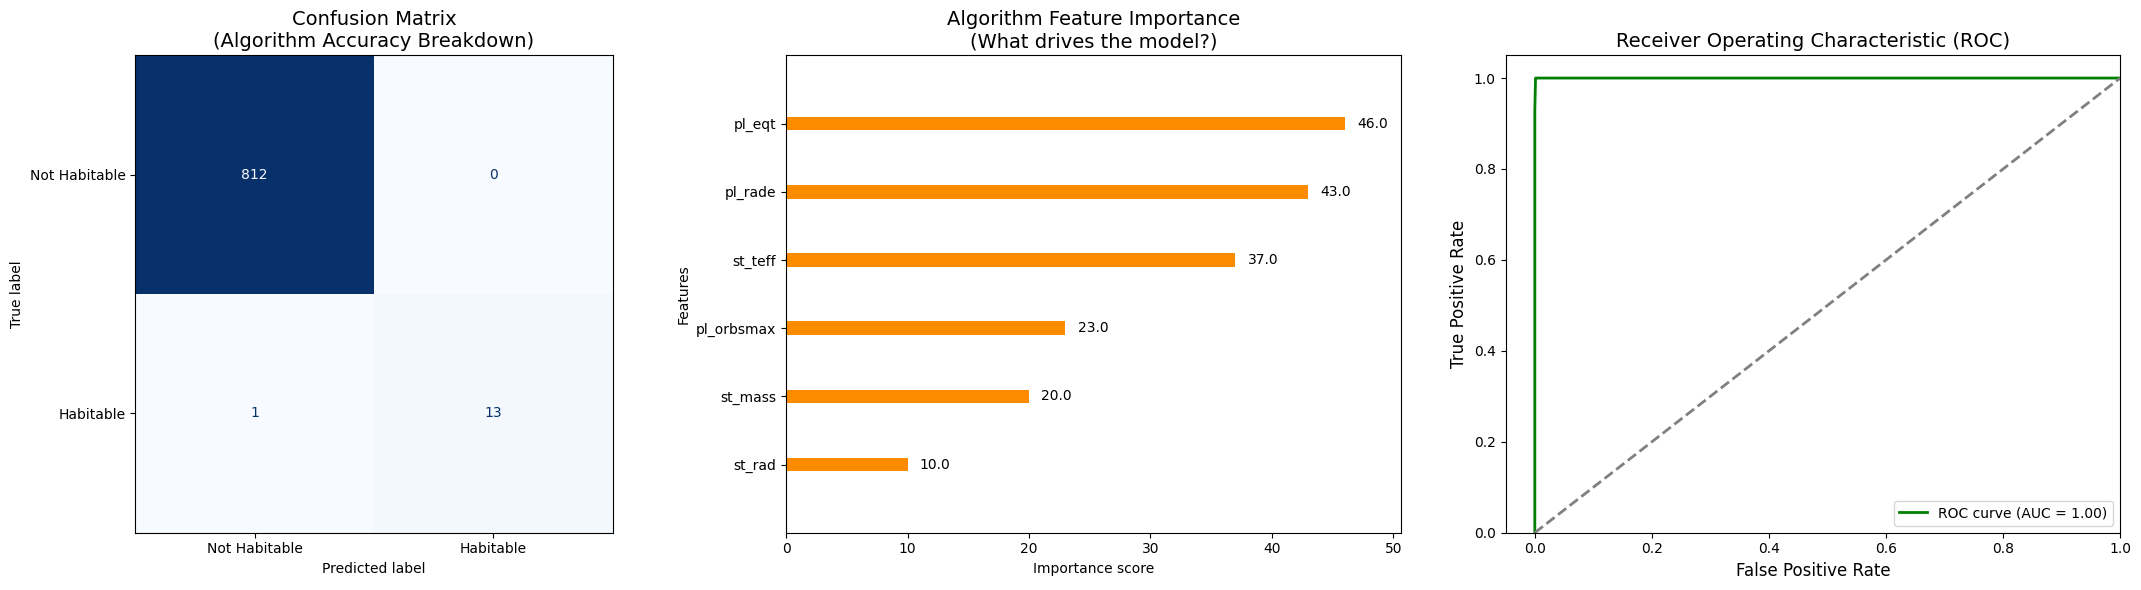

In [17]:
# --- Visualizations for the Algorithm's Work ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Habitable', 'Habitable'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Confusion Matrix\n(Algorithm Accuracy Breakdown)", fontsize=14)

# Graph 2: Feature Importance Graph
xgb.plot_importance(model, ax=axes[1], importance_type='weight', max_num_features=6, color='darkorange', grid=False)
axes[1].set_title("Algorithm Feature Importance\n(What drives the model?)", fontsize=14)

# Graph 3: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[2].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[2].set_xlim([-0.05, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate', fontsize=12)
axes[2].set_ylabel('True Positive Rate', fontsize=12)
axes[2].set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [21]:
# 4a. Regression Model: Train XGBoost to Predict Planet Temperature
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.model_selection import train_test_split
import pandas as pd

# Features used to predict temperature (Distance and Star properties)
X_reg = df[['pl_orbsmax', 'st_teff', 'st_rad', 'st_mass']]
y_reg = df['pl_eqt']

# Split into 80% training and 20% testing
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.20, random_state=42)

print("Training XGBoost Regressor to predict planet temperatures...")
reg_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
reg_model.fit(X_train_reg, y_train_reg)

# Generate predictions and evaluate
y_pred_reg = reg_model.predict(X_test_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Mean Absolute Error (MAE): {mae:.2f} Kelvin")
print(f"R-squared Score: {r2:.2f} (1.0 is perfect)")

Training XGBoost Regressor to predict planet temperatures...
Mean Absolute Error (MAE): 44.05 Kelvin
R-squared Score: 0.96 (1.0 is perfect)


In [22]:
# 4b. Regression Model: Predict a specific Earth-like planet
# Planet Radius: 1.0, Distance: 1.0, Planet Temp: 288.0, Star Temp: 5780, Star Rad: 1.0, Star Mass: 1.0
earth_features = pd.DataFrame({
    'pl_orbsmax': [1.00], 
    'st_teff': [5780.00], 
    'st_rad': [1.00], 
    'st_mass': [1.00]
})

earth_pred_temp = reg_model.predict(earth_features)[0]
print(f"Predicted Temp for your inputted Earth-like planet: {earth_pred_temp:.2f} K (Actual is ~288 K)")

Predicted Temp for your inputted Earth-like planet: 330.48 K (Actual is ~288 K)


In [28]:
# 4c. Visualizations: Regression Output & "Where All Planets Fall"
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Actual vs Predicted values (How well the algorithm works)
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.4, color='purple', edgecolor='k')
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction Line')
axes[0].set_title("Regression Accuracy:\nActual vs. Predicted Temperature", fontsize=14)
axes[0].set_xlabel("Actual Temperature (Kelvin)", fontsize=12)
axes[0].set_ylabel("Predicted Temperature (Kelvin)", fontsize=12)
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle=':', alpha=0.6)



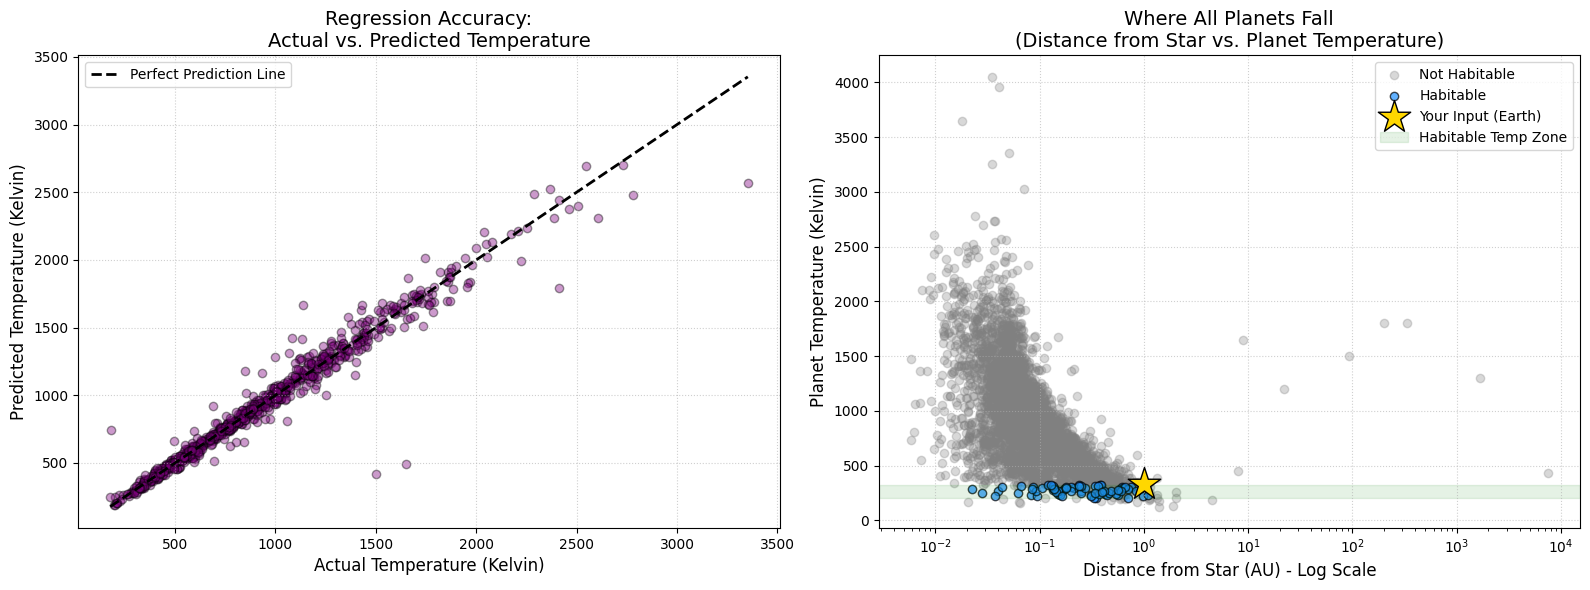

In [29]:
# Graph 2: Where all planets fall (Distance vs Temperature)
# Plot all non-habitable planets in gray
non_hab = df[df['is_habitable'] == 0]
axes[1].scatter(non_hab['pl_orbsmax'], non_hab['pl_eqt'], alpha=0.3, color='gray', label='Not Habitable')

# Plot all habitable planets in blue
hab = df[df['is_habitable'] == 1]
axes[1].scatter(hab['pl_orbsmax'], hab['pl_eqt'], alpha=0.7, color='dodgerblue', edgecolor='k', label='Habitable')

# Plot YOUR inputted planet as a giant Gold Star
axes[1].scatter([1.0], [earth_pred_temp], color='gold', edgecolor='black', marker='*', s=600, label='Your Input (Earth)', zorder=5)

axes[1].set_xscale('log') # Log scale because distances vary wildly
axes[1].set_title("Where All Planets Fall\n(Distance from Star vs. Planet Temperature)", fontsize=14)
axes[1].set_xlabel("Distance from Star (AU) - Log Scale", fontsize=12)
axes[1].set_ylabel("Planet Temperature (Kelvin)", fontsize=12)

# Highlight the habitable temperature zone (200K - 320K)
axes[1].axhspan(200, 320, color='green', alpha=0.1, label='Habitable Temp Zone')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [18]:
# 4. Interactive Dashboard using ipywidgets
style = {'description_width': 'initial'}
pl_rade_slider = widgets.FloatSlider(value=1.0, min=0.1, max=20.0, step=0.1, description='Planet Radius (Earth Radii):', style=style)
pl_orbsmax_slider = widgets.FloatSlider(value=1.0, min=0.01, max=5.0, step=0.01, description='Distance (AU):', style=style)
pl_eqt_slider = widgets.FloatSlider(value=288.0, min=100.0, max=1500.0, step=1.0, description='Planet Temp (K):', style=style)
st_teff_slider = widgets.FloatSlider(value=5778.0, min=2500.0, max=10000.0, step=10.0, description='Star Temp (K):', style=style)
st_rad_slider = widgets.FloatSlider(value=1.0, min=0.1, max=10.0, step=0.1, description='Star Radius (Solar):', style=style)
st_mass_slider = widgets.FloatSlider(value=1.0, min=0.1, max=10.0, step=0.1, description='Star Mass (Solar):', style=style)

predict_btn = widgets.Button(description="Predict Habitability", button_style='success')
output = widgets.Output()

def on_predict_clicked(b):
    with output:
        clear_output()
        features = np.array([[pl_rade_slider.value, pl_orbsmax_slider.value, pl_eqt_slider.value, st_teff_slider.value, st_rad_slider.value, st_mass_slider.value]])
        prob = model.predict_proba(features)[0][1]
        pred = model.predict(features)[0]
        
        if pred == 1:
            print(f"\033[1;32mHABITABLE (Probability: {prob*100:.2f}%)\033[0m")
        else:
            print(f"\033[1;31mNOT HABITABLE (Probability of being habitable: {prob*100:.2f}%)\033[0m")

predict_btn.on_click(on_predict_clicked)

display(pl_rade_slider, pl_orbsmax_slider, pl_eqt_slider, st_teff_slider, st_rad_slider, st_mass_slider, predict_btn, output)

FloatSlider(value=1.0, description='Planet Radius (Earth Radii):', max=20.0, min=0.1, style=SliderStyle(descri…

FloatSlider(value=1.0, description='Distance (AU):', max=5.0, min=0.01, step=0.01, style=SliderStyle(descripti…

FloatSlider(value=288.0, description='Planet Temp (K):', max=1500.0, min=100.0, step=1.0, style=SliderStyle(de…

FloatSlider(value=5778.0, description='Star Temp (K):', max=10000.0, min=2500.0, step=10.0, style=SliderStyle(…

FloatSlider(value=1.0, description='Star Radius (Solar):', max=10.0, min=0.1, style=SliderStyle(description_wi…

FloatSlider(value=1.0, description='Star Mass (Solar):', max=10.0, min=0.1, style=SliderStyle(description_widt…

Button(button_style='success', description='Predict Habitability', style=ButtonStyle())

Output()

In [8]:
# 5. Save the Model and Data for the API
import joblib

# Save the trained XGBoost model
joblib.dump(model, 'xgboost_planet_model.joblib')

# Save the dataset so the API can look up default planet features
df.to_csv('exoplanet_data.csv', index=False)

print("Model and dataset saved successfully! You can now load these in PLANET_API.py.")

Model and dataset saved successfully! You can now load these in PLANET_API.py.
